<a href="https://colab.research.google.com/github/institutohumai/cursos-python/blob/master/MachineLearning/9_SeriesDeTiempo/2.Prophet.ipynb"> <img src='https://colab.research.google.com/assets/colab-badge.svg' /> </a>
<div align="center"> Recordá abrir en una nueva pestaña </div>

# Prophet

## 🚀 ¿Qué es Prophet y cómo funciona?

**Prophet** es una herramienta de **predicción de series de tiempo** desarrollada por Facebook (Meta). Su objetivo es hacer **fácil y automatizado** el proceso de forecasting, incluso para personas sin conocimientos avanzados en estadística o machine learning.

Se basa en un **modelo aditivo**, donde la serie de tiempo se descompone en **tres componentes principales**:

1. **Tendencia (Trend):**  
   - Representa el crecimiento o decrecimiento general de la serie en el tiempo.  
   - Puede ser lineal o con saturación (cuando hay un límite de crecimiento).

2. **Estacionalidad (Seasonality):**  
   - Captura patrones que se repiten periódicamente (diarios, semanales, anuales).  
   - Por ejemplo, las ventas pueden subir los fines de semana y bajar entre semana.

3. **Eventos especiales (Holidays & Changepoints):**  
   - Prophet permite agregar días festivos, eventos promocionales o cualquier otro factor que pueda influir en la serie.  
   - También detecta automáticamente **cambios bruscos en la tendencia**.

---

## 📌 Ejemplo simple de uso

Supongamos que trabajas en una empresa de comercio electrónico y quieres predecir las ventas diarias para el próximo año.

1. **Tienes un historial de ventas de los últimos 3 años** con fechas y montos de ventas diarias.  
2. **Prophet analiza los datos y detecta patrones**, como:
   - **Aumento de ventas en diciembre** por Navidad.  
   - **Caída en enero** después de las fiestas.  
   - **Tendencia de crecimiento anual** debido al aumento de clientes.  
3. **El modelo genera una predicción** para los próximos 365 días, mostrando la tendencia esperada y posibles intervalos de confianza.

Además, puedes ajustar el modelo para incluir **días festivos, promociones o eventos inesperados** que puedan afectar las ventas.

---

## 🎯 Ventajas de usar Prophet

✔ **Fácil de usar:** No necesitas ser un experto en estadísticas.  
✔ **Automatiza la detección de tendencias y estacionalidad.**  
✔ **Maneja datos faltantes y valores atípicos sin problemas.**  
✔ **Permite personalización con eventos especiales.**  
✔ **Funciona bien con datos de negocios, tráfico web, finanzas y más.**

---

## 🔎 Conclusión

📌 Prophet es una gran opción para predecir **ventas, tráfico web, demanda de productos o cualquier serie de tiempo** de manera sencilla y confiable.



In [4]:
!pip install prophet

ERROR: Could not find a version that satisfies the requirement fprophet (from versions: none)
ERROR: No matching distribution found for fprophet


In [5]:
import itertools
import numpy as np
import pandas as pd
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_plotly
from matplotlib import pyplot as plt
from plotly import offline as py
plt.rcParams["figure.figsize"] = (20,5)


In [ ]:
# importamos datos abiertos del servicio de meteorologia y atmósfera
# link: https://www.ncdc.noaa.gov/data-access
# datos anuales desde 1880 a 2021

## Trabando sobre datos climáticos
importamos datos abiertos del servicio de meteorologia y atmósfera

link: https://www.ncdc.noaa.gov/data-access

datos anuales desde 1880 a 2021

In [6]:
data = pd.read_csv('https://storage.googleapis.com/humai-datasets/aws_s3/ml_avanzado/4_Series_de_tiempo/monthly_temp.csv')
data.ds = pd.to_datetime(data.ds)
train = data.copy()
train.head(10)

,ds,y
0,1895-01-01,26.69
1,1895-02-01,26.60
2,1895-03-01,39.97
3,1895-04-01,52.90
4,1895-05-01,59.94
5,1895-06-01,67.80
6,1895-07-01,71.24
7,1895-08-01,71.62
8,1895-09-01,65.57
9,1895-10-01,50.85


In [7]:
train.tail(10)

,ds,y
1509,2020-10-01,54.30
1510,2020-11-01,46.33
1511,2020-12-01,35.73
1512,2021-01-01,34.59
1513,2021-02-01,30.58
1514,2021-03-01,45.54
1515,2021-04-01,51.85
1516,2021-05-01,60.35
1517,2021-06-01,72.63
1518,2021-07-01,75.47


In [8]:
# generamos un dataset futuro para hacer la prediccion, desde
# 2021 a 2090
futuro = pd.DataFrame({'ds': pd.to_datetime(
    [x for x in range(2021, 2090)], format='%Y'), 'y': np.nan})

In [9]:
futuro.head()

,ds,y
0,2021-01-01,NaN
1,2022-01-01,NaN
2,2023-01-01,NaN
3,2024-01-01,NaN
4,2025-01-01,NaN


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmptc71qadn/5zftojvo.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmptc71qadn/k3oxpygg.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=41652', 'data', 'file=/tmp/tmptc71qadn/5zftojvo.json', 'init=/tmp/tmptc71qadn/k3oxpygg.json', 'output', 'file=/tmp/tmptc71qadn/prophet_modelp3ydyt6y/prophet_model-20250228190021.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
19:00:21 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
19:00:21 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


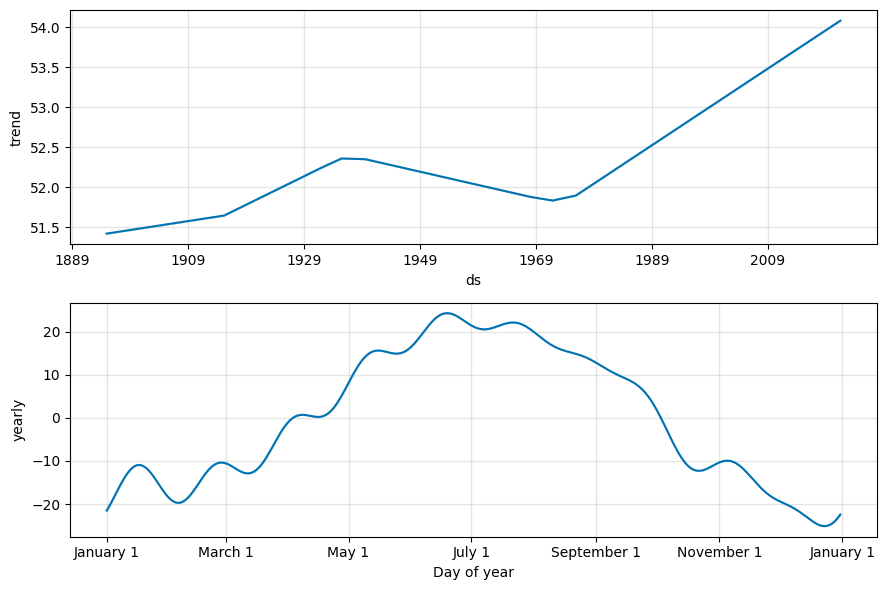

In [10]:
# instanciamos modelo
# si quisieramos setear parametros determinados segun nuestros datos, aqui es donde pasaríamos los hiperparametros correspondientes
m = Prophet()

# fiteamos el modelo en TRAIN
m.fit(train)

# predecimos en futuro
forecast = m.predict(futuro)

# para graficar, hacemos predict tambien en train
forecast_train = m.predict(train)

# #unimos los dos DFs para visualizar las dos partes, train-prediccion
forecast_final = pd.concat([forecast_train, forecast])

# #plot componentes del forecast
m.plot_components(forecast_train);

In [11]:
# vemos como prophet captura la estacionalidad anual (2do grafico) y la tendencia creciente (1er grafico).
# tener en cuenta que estos datos respecto a temperaturas son del hemisferio norte, de alli que en el segundo grafico vemos que hay una estacionalidad
# que nos indica temperaturas mas altas en julio y mas frias en enero

In [14]:
forecast_final.head(3)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1895-01-01,51.419366,27.708984,32.768255,51.419366,51.419366,-21.121707,-21.121707,-21.121707,-21.121707,-21.121707,-21.121707,0.0,0.0,0.0,30.297659
1,1895-02-01,51.420312,29.882609,35.103486,51.420312,51.420312,-18.840847,-18.840847,-18.840847,-18.840847,-18.840847,-18.840847,0.0,0.0,0.0,32.579465
2,1895-03-01,51.421166,38.170661,43.256695,51.421166,51.421166,-10.607642,-10.607642,-10.607642,-10.607642,-10.607642,-10.607642,0.0,0.0,0.0,40.813524


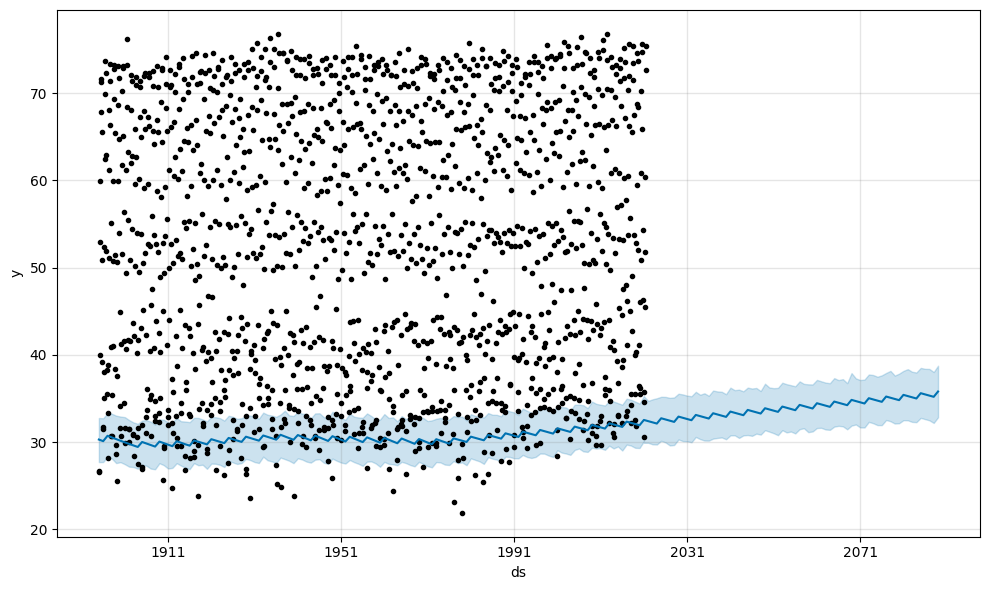

In [12]:
m.plot(forecast_final[forecast_final['ds'].dt.month==1])
plt.show()

In [15]:
# podemos pasar una grilla de hiperparámetros y probar con rolloing cross validation
# el set que minimiza el error. En este caso el MAE. Luego repetimos la prediccion
# con el mejor set de hiperparámetros.

# nombrar hiperparametros mas importantes, changepoint_prior_scale y changepoint range. como funcionan.
# prophet tambine puede recibir regresores de una matriz de datos.
# fechas de feriados para argentina y otros paises, etc.


param_grid = {
    'changepoint_prior_scale': [0.001, 0.05],  # default 0.05
    'seasonality_prior_scale': [10.0, 0.01, 1.0],  # default 10
    'seasonality_mode': ["additive", "multiplicative"]}


# Generate all combinations of parameters
all_params = [dict(zip(param_grid.keys(), v))
              for v in itertools.product(*param_grid.values())]
maes = []  # Store the MAEs for each params here
counter = 1
# Use cross validation to evaluate all parameters
for params in all_params:
    m = Prophet(**params)
    print(counter)
    counter = counter + 1

    m.fit(train)  # Fit model with given params

    initial_forecast_date = '1980-01-01'
    initial = str(
        abs(data[data.ds > initial_forecast_date].shape[0] - data.shape[0])) + ' days'

# tendremos 100 años de entrenamiento fijos
# luego haremos predicciones cada 10 años de 5 años de ventana de prediccion
# sucesivamente hasta que los datos se agoten.

    df_cv = cross_validation(
        m, initial='36500 days', period='3650 days', horizon='1825 days', parallel="processes")
    df_p = performance_metrics(df_cv, rolling_window=5)
    # rmses.append(df_p['rmse'].values[0])
    maes.append(df_p['mae'].values[0])  # USAMOS EL MAE


tuning_results = pd.DataFrame(all_params)

tuning_results['mae'] = maes
print(tuning_results)
best_params = all_params[np.argmin(maes)]
print(best_params)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmptc71qadn/ij5fvxxp.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmptc71qadn/gsvjjtn9.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=39782', 'data', 'file=/tmp/tmptc71qadn/ij5fvxxp.json', 'init=/tmp/tmptc71qadn/gsvjjtn9.json', 'output', 'file=/tmp/tmptc71qadn/prophet_model2p9e4_fp/prophet_model-20250228191004.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
19:10:04 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing


1


19:10:04 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:Making 3 forecasts with cutoffs between 1996-07-07 00:00:00 and 2016-07-02 00:00:00
INFO:prophet:Applying in parallel with <concurrent.futures.process.ProcessPoolExecutor object at 0x7b2d95f97a50>
DEBUG:cmdstanpy:input tempfile: /tmp/tmptc71qadn/klpi9ual.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmptc71qadn/jsc5hzit.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmptc71qadn/ziibs0bx.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmptc71qadn/f0351ea7.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=48856', 'data', 'file=/tmp/tmptc71qadn/klpi9ual.json', 'init=/tmp/tmptc71qadn/f0351ea7.json', 'output', 'file=/tmp/tmptc71qadn/prophet_modelxdtnm0yb/prophet_model-20250

2


19:10:05 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:Making 3 forecasts with cutoffs between 1996-07-07 00:00:00 and 2016-07-02 00:00:00
INFO:prophet:Applying in parallel with <concurrent.futures.process.ProcessPoolExecutor object at 0x7b2d95926990>
DEBUG:cmdstanpy:input tempfile: /tmp/tmptc71qadn/lz4islmv.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmptc71qadn/ar8a96vs.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmptc71qadn/xavcygsn.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=10905', 'data', 'file=/tmp/tmptc71qadn/lz4islmv.json', 'init=/tmp/tmptc71qadn/xavcygsn.json', 'output', 'file=/tmp/tmptc71qadn/prophet_modelsl2n7zgz/prophet_model-20250228191005.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
19:10:05 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdsta

...

11


19:10:21 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:Making 3 forecasts with cutoffs between 1996-07-07 00:00:00 and 2016-07-02 00:00:00
INFO:prophet:Applying in parallel with <concurrent.futures.process.ProcessPoolExecutor object at 0x7b2d95a63150>
DEBUG:cmdstanpy:input tempfile: /tmp/tmptc71qadn/lklz8klw.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmptc71qadn/es9lzhxt.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmptc71qadn/y_6afaux.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=32843', 'data', 'file=/tmp/tmptc71qadn/lklz8klw.json', 'init=/tmp/tmptc71qadn/y_6afaux.json', 'output', 'file=/tmp/tmptc71qadn/prophet_modelxp8kui__/prophet_model-20250228191021.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
19:10:21 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdsta

12


19:10:23 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:Making 3 forecasts with cutoffs between 1996-07-07 00:00:00 and 2016-07-02 00:00:00
INFO:prophet:Applying in parallel with <concurrent.futures.process.ProcessPoolExecutor object at 0x7b2d9584fb50>
DEBUG:cmdstanpy:input tempfile: /tmp/tmptc71qadn/up4fo2mz.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmptc71qadn/1lotl15i.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmptc71qadn/yz9uyv6b.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=88839', 'data', 'file=/tmp/tmptc71qadn/up4fo2mz.json', 'init=/tmp/tmptc71qadn/yz9uyv6b.json', 'output', 'file=/tmp/tmptc71qadn/prophet_modeleacq12og/prophet_model-20250228191023.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
19:10:23 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdsta

    changepoint_prior_scale  seasonality_prior_scale seasonality_mode  \
0                     0.001                    10.00         additive   
1                     0.001                    10.00   multiplicative   
2                     0.001                     0.01         additive   
3                     0.001                     0.01   multiplicative   
4                     0.001                     1.00         additive   
5                     0.001                     1.00   multiplicative   
6                     0.050                    10.00         additive   
7                     0.050                    10.00   multiplicative   
8                     0.050                     0.01         additive   
9                     0.050                     0.01   multiplicative   
10                    0.050                     1.00         additive   
11                    0.050                     1.00   multiplicative   

         mae  
0   1.599349  
1   1.647475  
2   1

In [17]:
# el mejor set de hiperparámetros
best_params

{'changepoint_prior_scale': 0.05,
 'seasonality_prior_scale': 0.01,
 'seasonality_mode': 'multiplicative'}

## Análisis del código anterior

Este código realiza ajuste de hiperparámetros para un modelo de predicción de series de tiempo usando Prophet. La idea principal es evaluar diferentes combinaciones de parámetros del modelo y elegir la mejor configuración según el Error Absoluto Medio (MAE) utilizando validación cruzada.

Paso a paso:

1. Definición del espacio de búsqueda de hiperparámetros ```param_grid```:
Se define un diccionario llamado param_grid que contiene las combinaciones de valores que se probarán para ciertos parámetros del modelo de Prophet:

```changepoint_prior_scale```: Controla la flexibilidad del modelo para ajustar cambios en la tendencia (cambio abrupto en los datos). Valores pequeños como 0.001 hacen que el modelo sea más rígido, mientras que valores más grandes (0.05) permiten que el modelo se ajuste más fácilmente a los cambios de tendencia.

```seasonality_prior_scale```: Controla la flexibilidad del modelo para ajustar la estacionalidad. Al igual que el anterior, valores más grandes permiten que el modelo capture mejor la estacionalidad en los datos.

```seasonality_mode```: Determina cómo se modela la estacionalidad. Puede ser aditiva (agregar los efectos estacionales a la tendencia) o multiplicativa (multiplicar los efectos estacionales por la tendencia). La opción multiplicativa puede ser útil cuando la magnitud de la estacionalidad cambia con la tendencia.

2. Generación de todas las combinaciones posibles de parámetros (```all_params```)
El código usa la función ```itertools.product``` para generar todas las combinaciones posibles de los valores de los parámetros definidos en ```param_grid```. Por ejemplo, si tienes 2 valores posibles para ```changepoint_prior_scale``` (0.001, 0.05) y 3 valores para ```seasonality_prior_scale``` (10.0, 0.01, 1.0), generará 6 combinaciones (producto cartesiano).

```python
all_params = [dict(zip(param_grid.keys(), v))
              for v in itertools.product(*param_grid.values())]
all_params es ahora una lista que contiene diccionarios con todas las combinaciones de parámetros.
```

3. Evaluación de las combinaciones de parámetros
Para cada combinación de parámetros en ```all_params```, el código crea un modelo de Prophet con esos parámetros y lo ajusta a los datos de entrenamiento.

```python
for params in all_params:
    m = Prophet(**params)
    m.fit(train)  # Ajustar el modelo con los datos de entrenamiento
```

4. Configuración de la validación cruzada (cross-validation)
Después de ajustar el modelo con los parámetros seleccionados, se realiza una validación cruzada con la función cross_validation de Prophet:

```python
df_cv = cross_validation(
    m, initial='36500 days', period='3650 days', horizon='1825 days', parallel="processes")
```

* ```initial```='36500 days': Los primeros 100 años de datos se usan como entrenamiento.
* ```period```='3650 days': El modelo se evalúa cada 10 años (3650 días).
* ```horizon```='1825 days': Se predicen 5 años (1825 días) por cada ventana de evaluación.

Este proceso de validación cruzada evalúa el rendimiento del modelo para diferentes ventanas de predicción y devuelve los resultados.

5. Cálculo del MAE y almacenamiento de los resultados
El código obtiene las métricas de rendimiento del modelo, específicamente el Error Absoluto Medio (MAE), y las guarda en una lista llamada maes para cada conjunto de parámetros:

```python
df_p = performance_metrics(df_cv, rolling_window=5)
maes.append(df_p['mae'].values[0])  # Usamos el MAE
```

6. Resultados finales
Finalmente, los resultados se organizan en un DataFrame de Pandas llamado tuning_results, donde cada fila contiene los parámetros y el correspondiente MAE para cada combinación probada.

```python
tuning_results = pd.DataFrame(all_params)
tuning_results['mae'] = maes
print(tuning_results)
```

7. Selección de los mejores parámetros
Después de evaluar todas las combinaciones de parámetros, se seleccionan los que producen el menor MAE, lo que indica que es el modelo con mejor rendimiento.

```python
best_params = all_params[np.argmin(maes)]
print(best_params)
```

### Resumen:
```param_grid``` define los parámetros a probar.
Se generan todas las combinaciones posibles de estos parámetros.
Para cada combinación, se entrena un modelo Prophet y se evalúa mediante validación cruzada.
El modelo se evalúa utilizando MAE y se almacenan los resultados.
Finalmente, se selecciona la mejor combinación de parámetros según el menor MAE.
Este proceso es muy útil cuando necesitas ajustar hiperparámetros de un modelo y asegurarte de que estás utilizando la configuración que da las mejores predicciones para tu conjunto de datos.

---

### Validación cruzada

La validación cruzada (cross-validation) en Prophet es una técnica importante para evaluar cómo se desempeña un modelo de series de tiempo al hacer predicciones sobre datos no vistos. En lugar de simplemente ajustar el modelo a todos los datos y hacer una única predicción, se evalúa el modelo utilizando diferentes partes del conjunto de datos para simular cómo sería su rendimiento en datos futuros. En el caso de Prophet, esto se hace de una forma adaptada a las series de tiempo, donde no se puede mezclar los datos de entrenamiento y prueba de manera aleatoria, como se hace con otros modelos.

#### Parámetros del cross_validation de Prophet

```python
df_cv = cross_validation(
    m,
    initial='36500 days',
    period='3650 days',
    horizon='1825 days',
    parallel="processes"
)
```

* ```m```: Este es el modelo de Prophet que ya has creado y ajustado a tus datos de entrenamiento.
* ```initial``` (Ejemplo: '36500 days'):
Este parámetro indica la cantidad de datos que se utilizan para entrenar el modelo inicialmente.
En este ejemplo, '36500 days' es igual a 100 años. Esto significa que, al principio de la validación cruzada, Prophet entrenará el modelo utilizando los primeros 100 años de datos.
Este valor es importante porque refleja la cantidad de datos históricos que el modelo necesita para aprender correctamente la tendencia y la estacionalidad. Si se establece un valor pequeño, el modelo podría no tener suficiente información para aprender patrones significativos.
* ```period``` (Ejemplo: '3650 days'):
Este parámetro define el intervalo de tiempo entre cada "re-entrenamiento" del modelo.
En este caso, '3650 days' es igual a 10 años. Esto significa que cada 10 años el modelo volverá a ser entrenado con datos más recientes.
La idea es simular cómo se actualizaría el modelo a medida que se generan nuevos datos, lo cual es especialmente útil cuando los patrones en la serie de tiempo pueden cambiar con el tiempo.
Al usar este parámetro, puedes evaluar el modelo en diferentes puntos a lo largo del tiempo y ver cómo se adapta a nuevas condiciones.
* ```horizon``` (Ejemplo: '1825 days'):
Este parámetro define el horizonte de predicción o el número de días hacia el futuro que el modelo debe predecir para cada "ventana" de validación cruzada.
En este caso, '1825 days' es igual a 5 años. Es decir, el modelo debe hacer predicciones para los próximos 5 años después de cada reentrenamiento.
Este horizonte es el que se evalúa para medir el rendimiento del modelo, ya que muestra cuán bien predice el futuro a corto plazo.
Dependiendo del problema, el horizonte puede ser de días, semanas, meses, etc.
* ```parallel``` (Ejemplo: 'processes'):
Este parámetro permite realizar la validación cruzada de manera paralela, lo cual es útil si estás ejecutando múltiples experimentos y quieres acelerar el proceso.
Usar "processes" hace que Prophet ejecute la validación cruzada en paralelo utilizando múltiples procesos del sistema. Si no lo usas o lo pones como "none", la validación se ejecutará de manera secuencial.

#### ¿Cómo funciona la evaluación en cross_validation?
* Entrenamiento inicial: El modelo de Prophet comienza entrenando con los primeros 100 años de datos (definido por initial).

* Generación de predicciones: Luego, el modelo realiza predicciones para los próximos 5 años (definido por horizon) y mide qué tan bien se desempeña.

* Re-entrenamiento: Después, el modelo se reentrena con los datos más recientes, usando un intervalo de 10 años (definido por period), y hace nuevas predicciones.

* Repetición: Este proceso se repite varias veces, moviendo la ventana de entrenamiento y la ventana de predicción, hasta que se agoten los datos disponibles.

#### Por ejemplo:

1. En la primera iteración, el modelo se entrena con los primeros 100 años de datos y predice los próximos 5 años.
2. En la segunda iteración, el modelo se entrena con los primeros 100 años más los siguientes 10 años, y luego predice otros 5 años.
3. Así sucesivamente, se repite el proceso con los datos más recientes.

#### Resultados de la validación cruzada
Al final de la validación cruzada, el resultado es un DataFrame (df_cv) que contiene todas las predicciones hechas durante las diferentes iteraciones. Cada fila tiene una predicción hecha por el modelo y la correspondiente verdadera (real) observación de los datos. Luego, se utilizan métricas de rendimiento como RMSE (Root Mean Squared Error) o MAE (Mean Absolute Error) para evaluar cuán precisas fueron las predicciones.

#### Métricas de evaluación
El código que mencionas utiliza la función performance_metrics para calcular métricas como MAE:

```python
df_p = performance_metrics(df_cv, rolling_window=5)
maes.append(df_p['mae'].values[0])  # Guardamos el MAE
```

* ```performance_metrics``` toma los resultados de la validación cruzada (df_cv) y calcula varias métricas de rendimiento.
* ```mae``` (Error Absoluto Medio) mide la diferencia promedio entre los valores predichos y los reales, ignorando la dirección del error (si el modelo sobrestima o subestima).

#### Resumen de la validación cruzada
* El modelo se entrena con un conjunto inicial de datos.
* Se hacen predicciones para un horizonte definido en el futuro.
* El modelo se reentrena con datos más recientes en intervalos definidos (period).
* Este proceso se repite y se evalúa el rendimiento del modelo en cada iteración.
* Se calcula la precisión del modelo utilizando métricas como el MAE para comparar el rendimiento entre diferentes combinaciones de parámetros.
Este enfoque de validación cruzada es especialmente útil en series de tiempo, donde los datos no deben mezclarse de manera aleatoria, ya que la secuencia temporal es crucial para hacer predicciones precisas.